# <center> [Tutorial 1] 양자컴퓨팅의 기초: 양자 회로 이해</center>

---
## <span style="color:navy"> **1.Installation** </span>


In [ ]:
#!pip install pennylane-kq
#!pip install pennylane

In [ ]:
import pennylane as qml
import numpy as np

---
## <span style="color:navy"> **2. 실습을 통한 양자회로 이해: 선형대수 v.s. 양자회로** </span>

### <span style="color:gold"> **2-1 Dirac Notation and Mathematical Expression** </span>

![](images/schodinger_cat.png)

$$|\text{Alive}\rangle = \begin{pmatrix}
1 \\ 0
\end{pmatrix} \quad \text{and} \quad |\text{Dead}\rangle = \begin{pmatrix}
0 \\ 1 
\end{pmatrix}
$$

$$
|\psi\rangle = \alpha |\text{Alive}\rangle + \beta |\text{Dead}\rangle = \begin{pmatrix}
\alpha \\ \beta
\end{pmatrix}, \, \text{where} \, \alpha,\beta \in \mathbb{C}
$$



$$
\langle \psi | \psi \rangle = (|\psi\rangle)^\dagger \cdot |\psi\rangle = \begin{pmatrix}\alpha^\ast &\beta^\ast\end{pmatrix} \cdot \begin{pmatrix}\alpha\\ \beta \end{pmatrix} = |\alpha|^2 + |\beta|^2 = 1
$$

Outcome: "Alive" $\Longrightarrow$ $\text{Pr}(\text{Alive}) = |\langle \text{Alive}  | \psi \rangle|^2 = |\alpha|^2$ <br>
Outcome: "Dead" $\Longrightarrow$ $\text{Pr}(\text{Dead}) = |\langle \text{Dead} | \psi \rangle|^2 = |\beta|^2$ 

### <span style="color:gold"> **2-2 Quantum Bit(=Qubit) and Single-qubit Gates** </span>

#### **Quantum State of a qubit**

![](images/qubit.png)

$|\psi\rangle = \cos(\theta/2) |0\rangle + e^{i\varphi}\sin(\theta/2) |1\rangle $, where $0\le\theta < \pi$ and $0\le\varphi < 2\pi$.

#### **Single-qubit Gates**

<img src="images/1Qgates1.png" width="40%" height="40%">

Examples

$X|0\rangle = |1\rangle$ <br>
$H|1\rangle = |-\rangle := (|0\rangle-|1\rangle) / \sqrt{2}$ <br>
$Z|-\rangle = |+\rangle := (|0\rangle+|1\rangle) / \sqrt{2}$ <br>
$Y|+\rangle = (-i|0\rangle+i|1\rangle) / \sqrt{2}$

In [7]:
dev = qml.device("default.qubit", wires=1)
@qml.qnode(dev)
def circuit_1Qgates():
    qml.PauliX(wires=0)
    #qml.H(wires=0)
    #qml.PauliZ(wires=0)
    #qml.PauliY(wires=0)
    return qml.state()

circuit_1Qgates()

array([0.+0.j, 1.+0.j])

#### **Parametrized Single-qubit Gates**

<img src="images/1Qgates2.png" width="60%" height="60%">

In [8]:
@qml.qnode(dev)
def circuit_1Qstate(theta, phi):
    qml.RY(phi=theta, wires=0)
    qml.RZ(phi=phi, wires=0)
    return qml.state()

$R_z(\varphi)R_y(\theta)|0\rangle = e^{-i\varphi/2} \cos(\theta/2)|0\rangle + e^{i\varphi/2} \sin(\theta/2)|1\rangle$ <br>
$e^{i\varphi/2}R_z(\varphi)R_y(\theta)|0\rangle = \cos(\theta/2) |0\rangle + e^{i\varphi/2} \sin(\theta/2)|1\rangle$

In [9]:
# |0> + i|1> / sqrt(2)
np.exp(1j*np.pi/4) * circuit_1Qstate(np.pi/2, np.pi/2) 

array([7.07106781e-01+0.j        , 1.11022302e-16+0.70710678j])

### <span style="color:gold"> **2-3 Two-qubit States & Two-qubit Gates** </span>

#### **Two-qubit State**

$|\psi_1\rangle = a|0\rangle + b|1\rangle$ and $|\psi_2\rangle = c|0\rangle + d|1\rangle$


$|\Psi\rangle = |\psi_1\rangle|\psi_2\rangle = (a|0\rangle + b|1\rangle) \otimes (c|0\rangle + d|1\rangle)=ac|00\rangle + ad|01\rangle + bc|10\rangle + bd|11\rangle=\begin{pmatrix} ac\\ad\\bc\\bd \end{pmatrix}$<br>

Check: $(Y\otimes X)|\Psi\rangle = (Y|\psi_1\rangle)\otimes (X|\psi_2\rangle)$

#### **Two-qubit Gates**<br>

<img src="images/2Qgates.png" width="70%" height="60%">

In [10]:
dev1 = qml.device("default.qubit", wires=2)
@qml.qnode(dev1)
def circuit_2Q():
    qml.X(wires=0)
    qml.CNOT(wires=[0,1])
    qml.CZ(wires=[0,1])
    return qml.state()
circuit_2Q()

array([ 0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j])

$SWAP|+\rangle|0\rangle = |0\rangle|+\rangle$

In [11]:
dev1 = qml.device("default.qubit", wires=2)
@qml.qnode(dev1)
def circuit_2Q():
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0,1])
    qml.CNOT(wires=[1,0])
    qml.CNOT(wires=[0,1])
    return qml.state()
circuit_2Q()

array([0.70710678+0.j, 0.70710678+0.j, 0.        +0.j, 0.        +0.j])

<img src="images/su4gate.png" width="60%" height="60%">

In [12]:
def su4(wires, params):
    return 0

#### **Two-qubit Separable and Entangled States**

Arbitraty two-qubit pure state: $|\Psi\rangle = \sum_{i,j=0}^1 c_{\,i,j}|i\rangle|j\rangle$

Separable state : $|\Psi\rangle = |\psi\rangle\otimes|\phi\rangle$. <br>
Entangled state $\leftrightarrow$ $|\Psi\rangle$ is not separable. 


Example:   <br>
$|\Psi\rangle = \cos(\theta/2) |00\rangle + \sin(\theta/2) |11\rangle$ is  <br>
separable if $\theta = 0, \pi/2$ <br>
entangled otherwise 

In [13]:
dev1 = qml.device("default.qubit", wires=2)
@qml.qnode(dev1)
def circuit_Psi(theta=0):
    qml.RY(phi=theta, wires=0)
    qml.CNOT(wires=[0,1])
    return qml.state()

circuit_Psi(2*np.pi/3)

array([0.5      +0.j, 0.       +0.j, 0.       +0.j, 0.8660254+0.j])

(<Figure size 500x300 with 1 Axes>, <Axes: >)

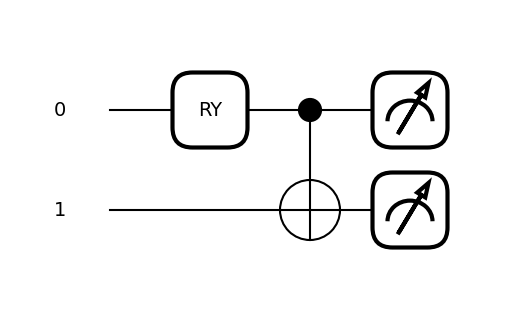

In [14]:
qml.draw_mpl(circuit_Psi)()

### <span style="color:gold"> **2-4 Multi-qubit Gates** </span>

Toffoli Gate

(<Figure size 500x500 with 1 Axes>, <Axes: >)

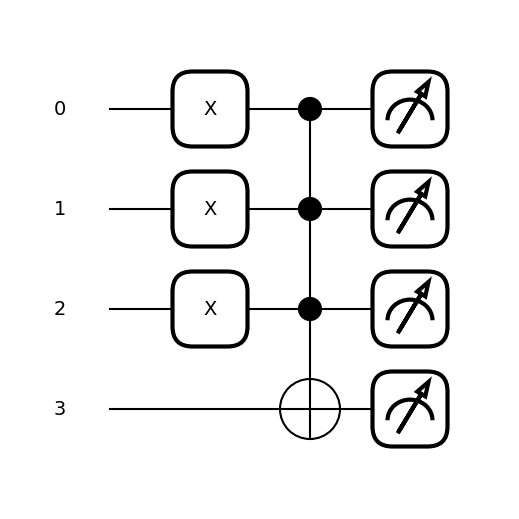

In [15]:
n_qubits = 4
dev2 = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev2)
def circuit_Toffoli(n_qubits):
    for i in range(n_qubits-1):
        qml.X(wires=i)
    qml.MultiControlledX(wires=range(n_qubits))
    return qml.state()
qml.draw_mpl(circuit_Toffoli)(n_qubits)

In [16]:
circuit_Toffoli(n_qubits)

array([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j])

### <span style="color:gold"> **2-5 Measurement in the Quantum Circuit** </span>

#### **$Z$-basis measurement**

Pauli $Z$ operator : $Z = \begin{pmatrix}
1 & 0\\
0  & -1
\end{pmatrix} = (+1)|0\rangle\langle 0| + (-1)|1\rangle\langle 1|$

**Projection-Valued Measurement**: $\{\hat{M}_0 = |0\rangle\langle 0|, \hat{M}_{1} = |1\rangle\langle 1|\}$, where $\hat{M}_m$: projection operator. <br>
* Outcome: $m\in\{0,1\}$ <br>
* Probability: $p(m) = \langle\psi|M_m^\dagger M_m|\psi\rangle$ <br>
* Post-measurement state: $M_m|\psi\rangle/p(m)$

#### **Example**

$|\psi\rangle = \cos(\theta/2)|0\rangle + \sin(\theta/2)|1\rangle$<br>
$p(0) = \langle\psi|\hat{M}^\dagger_{0}\hat{M}_{0}|\psi\rangle = |\cos(\theta/2)|^2$ <br>
$p(1) = \langle\psi|\hat{M}^\dagger_{1}\hat{M}_{1}|\psi\rangle = |\sin(\theta/2)|^2$

In [61]:
@qml.qnode(dev)
def circuit_state(theta=np.pi/2):
    qml.RY(theta, wires=0)
    return qml.state()

@qml.qnode(dev)
def circuit_probs(theta=np.pi/2):
    qml.RY(theta, wires=0)
    return qml.probs(wires=0)

@qml.set_shots(20)
@qml.qnode(dev)
def circuit_sample(theta=np.pi/2):
    qml.RY(theta, wires=0)
    return qml.sample()

@qml.set_shots(20)
@qml.qnode(dev)
def circuit_counts(theta=np.pi/2):
    qml.RY(theta, wires=0)
    return qml.counts()

In [67]:
theta0 = np.pi/2
print("State:", circuit_state(theta0))
print("Probs:", circuit_probs(theta0))
print("Counts:", circuit_counts(theta0))
print("Sample:", circuit_sample(theta0))

State: [0.70710678+0.j 0.70710678+0.j]
Probs: [0.5 0.5]
Counts: {np.str_('0'): np.int64(6), np.str_('1'): np.int64(14)}
Sample: [[1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]]


---
## <span style="color:navy"> **3. Two Examples** </span>

### <span style="color:gold"> **3-1 GHZ state** </span>

$$
|GHZ\rangle = \frac{1}{\sqrt{2^N}} (|0\rangle^{\otimes N}+|1\rangle^{\otimes N})
$$

In [69]:
n_qubits = 4
dev_nq = qml.device("default.qubit", wires=n_qubits)

In [ ]:
@qml.set_shots(1000)
@qml.qnode(dev_nq)
def circuit_GHZ(n_qubits):
    ???
    ???
    return qml.counts()

In [76]:
circuit_GHZ(n_qubits)

{np.str_('0000'): np.int64(507), np.str_('1111'): np.int64(493)}

### <span style="color:gold"> **3-2 CHSH gate** </span>

Example

1. GHZ states?
2. CHSH game